In [7]:
import numpy as np
import matplotlib.pyplot as plt
import astropy
from astropy.cosmology import Planck15
import astropy.cosmology as cosmo
import astropy.units as u
import matplotlib.colors as mcolors
import pandas as pd
import seaborn as sns
import matplotlib.patheffects as path_effects
from tqdm import tqdm
import dill
import matplotlib.gridspec as gridspec
#from matplotlib.lines import Line2D 
import matplotlib.patches as mpatches  
%run /home/jessica/Jess/Projects/Ongoing/Cosmography/Python/Colab/wcdm_expansions.ipynb

# Download samples

In [2]:
def log_probability(theta, func, z, data, order):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp - chi_square(list(theta), func, z, data, order)

In [3]:
# Open the file and load the sampler object
with open("sampler_log.pkl", "rb") as f:
    sampler_order_log = dill.load(f)

# with open("sampler_z.pkl", "rb") as f:
#     sampler_order_z = dill.load(f)

with open("sampler_pade21.pkl", "rb") as f:
    sampler_pade21 = dill.load(f)

with open("sampler_pade22.pkl", "rb") as f:
    sampler_pade22 = dill.load(f)

with open("sampler_pade32.pkl", "rb") as f:
    sampler_pade32 = dill.load(f)

with open("sampler_pade42.pkl", "rb") as f:
    sampler_pade42 = dill.load(f)

with open("sampler_EIS_true_2_GRB_with_sigma_newer.pkl", "rb") as f:
    sampler_eis2 = dill.load(f) 

with open("sampler_EIS_true_3_GRB_with_sigma_newer.pkl", "rb") as f:
    sampler_eis3 = dill.load(f)
    
with open("sampler_EIS_true_4_GRB_with_sigma_newer.pkl", "rb") as f:
    sampler_eis4 = dill.load(f)

with open("sampler_EIS_true_5_GRB_with_sigma_newer.pkl", "rb") as f:
    sampler_eis5 = dill.load(f)
    
with open("sampler_EIS_true_6_GRB_with_sigma_newer.pkl", "rb") as f:
    sampler_eis6 = dill.load(f)


# Concatenate the chains along the first axis
sampler_pade = np.concatenate([sampler_pade21, sampler_pade22, sampler_pade32, sampler_pade42], axis=0)
sampler_eis = np.stack([sampler_eis2, sampler_eis3, sampler_eis4, sampler_eis5, sampler_eis6], axis=0)

In [4]:
# Open the file and load the sampler object
with open("/home/jessica/Jess/Projects/Ongoing/Cosmography/Python/Colab/MCMC/GRB_without_H0/sampler_log.pkl", "rb") as f:
    sampler_order_log_noH = dill.load(f)

# with open("/home/jessica/Jess/Projects/Ongoing/Cosmography/Python/Colab/MCMC/GRB_without_H0/sampler_z.pkl", "rb") as f:
#     sampler_order_z_noH = dill.load(f)

with open("/home/jessica/Jess/Projects/Ongoing/Cosmography/Python/Colab/MCMC/GRB_without_H0/sampler_pade21.pkl", "rb") as f:
    sampler_pade21_noH = dill.load(f)

with open("/home/jessica/Jess/Projects/Ongoing/Cosmography/Python/Colab/MCMC/GRB_without_H0/sampler_pade22.pkl", "rb") as f:
    sampler_pade22_noH = dill.load(f)

with open("/home/jessica/Jess/Projects/Ongoing/Cosmography/Python/Colab/MCMC/GRB_without_H0/sampler_pade32.pkl", "rb") as f:
    sampler_pade32_noH = dill.load(f)

with open("/home/jessica/Jess/Projects/Ongoing/Cosmography/Python/Colab/MCMC/GRB_without_H0/sampler_pade42.pkl", "rb") as f:
    sampler_pade42_noH = dill.load(f)


with open("/home/jessica/Jess/Projects/Ongoing/Cosmography/Python/Colab/MCMC/GRB_without_H0/sampler_EIS_true_2_minus_GRB_with_sigma_without_H0_newer.pkl", "rb") as f:
    sampler_eis2_noH = dill.load(f) 

with open("/home/jessica/Jess/Projects/Ongoing/Cosmography/Python/Colab/MCMC/GRB_without_H0/sampler_EIS_true_3_minus_GRB_with_sigma_without_H0_newer.pkl", "rb") as f:
    sampler_eis3_noH = dill.load(f)
    
with open("/home/jessica/Jess/Projects/Ongoing/Cosmography/Python/Colab/MCMC/GRB_without_H0/sampler_EIS_true_4_minus_GRB_with_sigma_without_H0_newer.pkl", "rb") as f:
    sampler_eis4_noH = dill.load(f)

with open("/home/jessica/Jess/Projects/Ongoing/Cosmography/Python/Colab/MCMC/GRB_without_H0/sampler_EIS_true_5_minus_GRB_with_sigma_without_H0_newer.pkl", "rb") as f:
    sampler_eis5_noH = dill.load(f)
    
with open("/home/jessica/Jess/Projects/Ongoing/Cosmography/Python/Colab/MCMC/GRB_without_H0/sampler_EIS_true_6_minus_GRB_with_sigma_without_H0_newer.pkl", "rb") as f:
    sampler_eis6_noH = dill.load(f)

# Concatenate the chains along the first axis
sampler_pade_noH = np.concatenate([sampler_pade21_noH, sampler_pade22_noH, sampler_pade32_noH, sampler_pade42_noH], axis=0)
sampler_eis_noH = np.stack([sampler_eis2_noH, sampler_eis3_noH, sampler_eis4_noH, sampler_eis5_noH, sampler_eis6_noH], axis=0)

In [5]:
# Open the file and load the sampler object
with open("/home/jessica/Jess/Projects/Ongoing/Cosmography/Python/Colab/MCMC/GRB_extended_sample_withH0/sampler_log.pkl", "rb") as f:
    sampler_order_log_ext = dill.load(f)

# with open("/home/jessica/Jess/Projects/Ongoing/Cosmography/Python/Colab/MCMC/GRB_extended_sample_withH0/sampler_z.pkl", "rb") as f:
#     sampler_order_z_noH = dill.load(f)

with open("/home/jessica/Jess/Projects/Ongoing/Cosmography/Python/Colab/MCMC/GRB_extended_sample_withH0/sampler_pade21.pkl", "rb") as f:
    sampler_pade21_ext = dill.load(f)

with open("/home/jessica/Jess/Projects/Ongoing/Cosmography/Python/Colab/MCMC/GRB_extended_sample_withH0/sampler_pade22.pkl", "rb") as f:
    sampler_pade22_ext = dill.load(f)

with open("/home/jessica/Jess/Projects/Ongoing/Cosmography/Python/Colab/MCMC/GRB_extended_sample_withH0/sampler_pade32.pkl", "rb") as f:
    sampler_pade32_ext = dill.load(f)

with open("/home/jessica/Jess/Projects/Ongoing/Cosmography/Python/Colab/MCMC/GRB_extended_sample_withH0/sampler_pade42.pkl", "rb") as f:
    sampler_pade42_ext = dill.load(f)

# with open("/home/jessica/Jess/Projects/Ongoing/Cosmography/Python/Colab/MCMC/GRB_extended_sample_withH0/sampler_pade51.pkl", "rb") as f:
#     sampler_pade51_noH = dill.load(f)

# Concatenate the chains along the first axis
sampler_pade_ext = np.concatenate([sampler_pade21_ext, sampler_pade22_ext, sampler_pade32_ext, sampler_pade42_ext], axis=0)

In [6]:
H0 =  73.5
Om = 0.334
Ok = 0.0
w = -1.0

def to_cosmographic( H0,Om, Ok, w):
    q0 = 1.0/2.0 *(1.0-Ok-3.0*(-1.0+Om+Ok)*w)
    j0 = 1 - Ok + (9/2)*(1.0-Om-Ok)*w*(1+w)
    s0 = -7/2 + 4*Ok -Ok**2/2 + (-81/4 + 15*Ok/4)*(1-Ok-Om)*w + (9*Ok/4 -117/4 -27*(1-Ok-Om)/4)*(1-Ok-Om)*w**2 -(27/4)*(3-Ok -Om)*(1-Ok-Om)*w**3
    c0 = 35/2 -23*Ok +11*Ok**2/2 +(489/4 -189*Ok/4)*(1-Ok-Om)*w +(207 + 189*(1-Ok -Om)/2 -99*Ok/2)*(1-Ok-Om)*w**2 +(621/4 + 162*(1- Ok - Om) -81/4*Ok)*(1- Ok - Om)*w**3 +81/2 *(1+2*(1-Ok -Om))*(1-Ok-Om)*w**4
    p0 = 1/4*(-455 +681*Ok -237*Ok**2 +11*Ok**3) +(-7407/8 +2187*Ok/4 -255*Ok**2/8)*(1.0-Om-Ok)*w \
         +(-6849/4 + 1449*Ok/2 -99*Ok**2/4 -9315*(1.0-Om-Ok)/8 +945*Ok*(1.0-Om-Ok)/8)*(1.0-Om-Ok)*w**2 \
         +(-13041/8 +1971*Ok/4 -81*Ok**2/8 -5103*(1.0-Om-Ok)/2 +621*Ok*(1.0-Om-Ok)/4 -567*(1.0-Om-Ok)*(1.0-Om-Ok)/4)*(1.0-Om-Ok)*w**3 \
         +(-729 +243*Ok/2 -17577*(1.0-Om-Ok)/8 +567*Ok*(1.0-Om-Ok)/8 -243*(1.0-Om-Ok)*(1.0-Om-Ok))*(1.0-Om-Ok)*w**4 \
         -243/4*(2+11*(1.0-Om-Ok)+2*(1.0-Om-Ok)*(1.0-Om-Ok))*(1.0-Om-Ok)*w**5
    return H0,q0, j0, s0, c0, p0

H0t, q0t, j0t, s0t, c0t, p0t = to_cosmographic(H0, Om, Ok, w)
theta_true = (H0t, q0t, j0t, s0t, c0t, p0t)
#print(theta_true)


# Matrix MCMC

In [7]:
def matrix_plot_posteriors2(title, theta_true, sampler1, sampler2, ordermin=0):
    # Unpack true parameter values
    H0t, q0t, j0t, s0t, c0t, p0t = theta_true

    H0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    q0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    j0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    s0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    c0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    p0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]

    for i in range(len(sampler1)):
        samples = sampler1[i].get_chain(discard=500, thin=10, flat=True)
        if len(samples[0])==2:
            H0_samples[i] = samples[:, 0]
            q0_samples[i] = samples[:, 1]
        elif len(samples[0]) ==3:
            H0_samples[i] = samples[:, 0]
            q0_samples[i] = samples[:, 1]
            j0_samples[i] = samples[:, 2]
        elif len(samples[0]) ==4:
            H0_samples[i] = samples[:, 0]
            q0_samples[i] = samples[:, 1]
            j0_samples[i] = samples[:, 2]
            s0_samples[i] = samples[:, 3]
        elif len(samples[0]) ==5:
            H0_samples[i] = samples[:, 0]
            q0_samples[i] = samples[:, 1]
            j0_samples[i] = samples[:, 2]
            s0_samples[i] = samples[:, 3]
            c0_samples[i] = samples[:, 4]
        else:
            H0_samples[i] = samples[:, 0]
            q0_samples[i] = samples[:, 1]
            j0_samples[i] = samples[:, 2]
            s0_samples[i] = samples[:, 3]
            c0_samples[i] = samples[:, 4]
            p0_samples[i] = samples[:, 5]

    q0_samples2 = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    j0_samples2 = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    s0_samples2 = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    c0_samples2 = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    p0_samples2 = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]

    for i in range(len(sampler2)):
        samples2 = sampler2[i].get_chain(discard=500, thin=10, flat=True)
        if len(samples2[0])==1:
            #H0_samples[i] = samples[:, 0]
            q0_samples2[i] = samples2[:, 0]
        elif len(samples2[0]) ==2:
            #H0_samples[i] = samples[:, 0]
            q0_samples2[i] = samples2[:, 0]
            j0_samples2[i] = samples2[:, 1]
        elif len(samples2[0]) ==3:
            #H0_samples[i] = samples[:, 0]
            q0_samples2[i] = samples2[:, 0]
            j0_samples2[i] = samples2[:, 1]
            s0_samples2[i] = samples2[:, 2]
        elif len(samples2[0]) ==4:
            #H0_samples[i] = samples[:, 0]
            q0_samples2[i] = samples2[:, 0]
            j0_samples2[i] = samples2[:, 1]
            s0_samples2[i] = samples2[:, 2]
            c0_samples2[i] = samples2[:, 3]
        else:
            #H0_samples[i] = samples[:, 0]
            q0_samples2[i] = samples2[:, 0]
            j0_samples2[i] = samples2[:, 1]
            s0_samples2[i] = samples2[:, 2]
            c0_samples2[i] = samples2[:, 3]
            p0_samples2[i] = samples2[:, 4]

    # Number of columns (based on the ordermin parameter)
    order = len(sampler1) #5  -ordermin
    pars = 6
    
    # List of samples and true values for easy access
    samples_list = [H0_samples, q0_samples, j0_samples, s0_samples, c0_samples, p0_samples]
    samples_list2 = [[np.full(1,np.nan)], q0_samples2, j0_samples2, s0_samples2, c0_samples2, p0_samples2]
    true_values = [H0t, q0t, j0t, s0t, c0t, p0t]
    
    # Labels for the parameters
    param_labels = ['$H_0$', '$q_0$', '$j_0$', '$s_0$', '$c_0$', '$p_0$']
    order_labels = []
    for j in range(order):
        if title == 'Pade series':
            order_labels = ['Pade 21', 'Pade22', 'Pade32', 'Pade 42', 'Pade 51']
        else:
            order_labels.append('$\mathcal{O}(' + str(j+2+ordermin) + ')$')
    
    # Create the figure and axes for the matrix plot
    fig, axes = plt.subplots(order, pars, figsize=(15,10), sharex='col')
    # Set title for the entire figure
    fig.suptitle(f'{title} (GRB redshift sample)', fontsize=18, weight='bold')
    gs = gridspec.GridSpec(order, pars)

    # Loop through the grid and plot KDEs
    for i in range(order):
        for j in range(pars):
            ax = axes[ i,j]

            # Get the posterior samples and true value for the current parameter
            if ~np.isnan(samples_list[j][i][0]):  # Make sure there are samples
                samples = samples_list[j][i]
                true_val = true_values[j]

                if len(samples) > 0:  # Plot KDE only if samples exist
                    sns.kdeplot(samples, fill=True, ax=ax, alpha=0.5, legend=False, color= 'mediumslateblue')
                    plt.ylabel('')
                    # Plot the true value line
                    ax.axvline(true_val, color='black', linestyle='--')
                    if j == 0:
                        ax.set_ylabel(order_labels[i], fontsize=16, weight='bold')
                    else:
                        ax.set_ylabel('')

                # Remove density ylabel
            ax.set_yticks([])
            
            # Turn off empty cells
            if np.isnan(samples_list[j][i][0]):
                ax.axis('off')

            # Add parameter labels on the left side
            if i == order - 1:
                ax.set_xlabel(param_labels[j], fontsize=16, weight='bold')
                        
    for i in range(order-1):
        for j in range(pars-1):
            ax = axes[i+1, j+1]
            if ~np.isnan(samples_list2[j+1][i][0]):
                samples2 = samples_list2[j+1][i]#if i < len(samples_list[j]) else []
                if len(samples2) > 0:  # Plot KDE only if samples exist
                    sns.kdeplot(samples2, fill=True, ax=ax, alpha=0.3, legend=False, color= 'mediumturquoise')

    
    #  # Add legend on the top right corner
    # custom_lines = [Line2D([0], [0], color='mediumslateblue', lw=4, label='H0 as variable'),
    #                 Line2D([0], [0], color='mediumturquoise', lw=4, label='H0 fixed')]
    
    # fig.legend(handles=custom_lines, loc='upper right', fontsize=16)

    # Define the color boxes for the legend with matching alpha and colors
    sample1_patch = mpatches.Patch(color='mediumslateblue', alpha=0.6, label='H0 variable')
    sample2_patch = mpatches.Patch(color='mediumturquoise', alpha=0.4, label='H0 fixed')

    # Add the legend to the figure manually (place it in the top right corner)
    fig.legend(handles=[sample1_patch, sample2_patch], loc='upper right', bbox_to_anchor=(0.9, 0.8), fontsize=16)

    # Adjust layout to eliminate space between subplots
    plt.subplots_adjust(wspace=-4, hspace=-1)  # Remove horizontal/vertical spaces

    # Adjust layout to avoid overlap
    plt.tight_layout()
    plt.savefig(f'Posteriors_matrix_{title}_GRB_comparison.png', dpi=500,  bbox_inches='tight')  # To save as PNG

    # Show the plot
    plt.show()

<>:94: SyntaxWarning: invalid escape sequence '\m'
<>:94: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_113795/2161882046.py:94: SyntaxWarning: invalid escape sequence '\m'
  order_labels.append('$\mathcal{O}(' + str(j+2+ordermin) + ')$')


In [8]:
#sampler_order_log

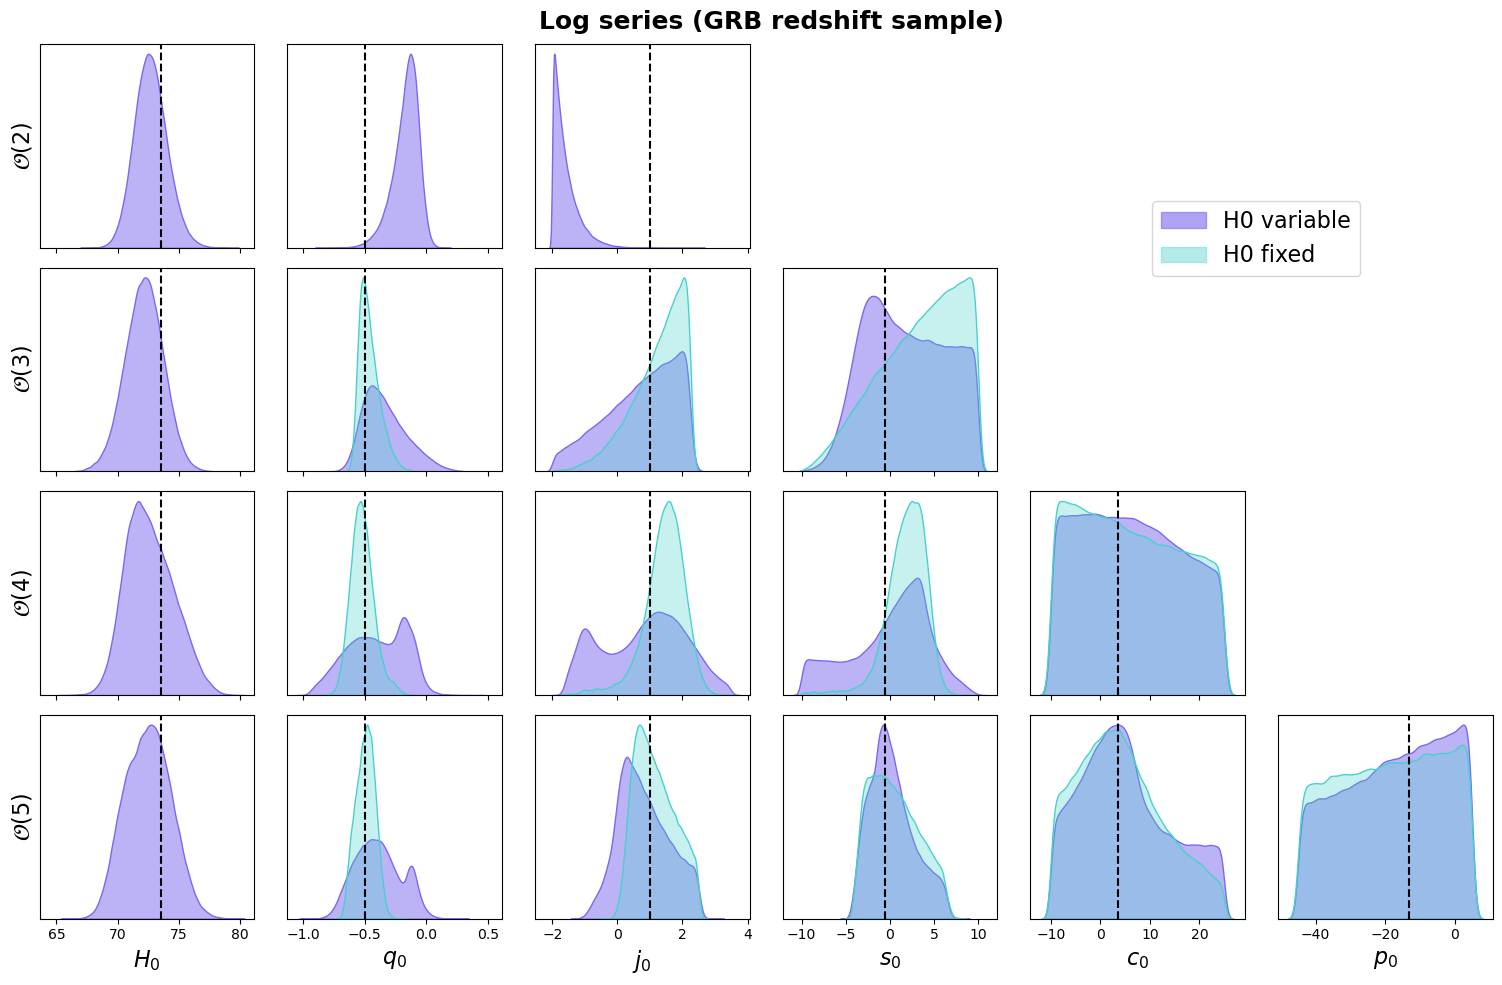

In [9]:
matrix_plot_posteriors2('Log series', theta_true, sampler_order_log, sampler_order_log_noH)

In [10]:
def matrix_plot_posteriors2pade(title, theta_true, sampler1, sampler2, ordermin=0):
    # Unpack true parameter values
    H0t, q0t, j0t, s0t, c0t, p0t = theta_true

    H0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    q0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    j0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    s0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    c0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    p0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]

    for i in range(len(sampler1)):
        samples = sampler1[i].get_chain(discard=500, thin=10, flat=True)
        if len(samples[0])==2:
            H0_samples[i] = samples[:, 0]
            q0_samples[i] = samples[:, 1]
        elif len(samples[0]) ==3:
            H0_samples[i] = samples[:, 0]
            q0_samples[i] = samples[:, 1]
            j0_samples[i] = samples[:, 2]
        elif len(samples[0]) ==4:
            H0_samples[i] = samples[:, 0]
            q0_samples[i] = samples[:, 1]
            j0_samples[i] = samples[:, 2]
            s0_samples[i] = samples[:, 3]
        elif len(samples[0]) ==5:
            H0_samples[i] = samples[:, 0]
            q0_samples[i] = samples[:, 1]
            j0_samples[i] = samples[:, 2]
            s0_samples[i] = samples[:, 3]
            c0_samples[i] = samples[:, 4]
        else:
            H0_samples[i] = samples[:, 0]
            q0_samples[i] = samples[:, 1]
            j0_samples[i] = samples[:, 2]
            s0_samples[i] = samples[:, 3]
            c0_samples[i] = samples[:, 4]
            p0_samples[i] = samples[:, 5]

    q0_samples2 = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    j0_samples2 = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    s0_samples2 = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    c0_samples2 = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    p0_samples2 = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]

    for i in range(len(sampler2)):
        samples2 = sampler2[i].get_chain(discard=500, thin=10, flat=True)
        if len(samples2[0])==1:
            #H0_samples[i] = samples[:, 0]
            q0_samples2[i] = samples2[:, 0]
        elif len(samples2[0]) ==2:
            #H0_samples[i] = samples[:, 0]
            q0_samples2[i] = samples2[:, 0]
            j0_samples2[i] = samples2[:, 1]
        elif len(samples2[0]) ==3:
            #H0_samples[i] = samples[:, 0]
            q0_samples2[i] = samples2[:, 0]
            j0_samples2[i] = samples2[:, 1]
            s0_samples2[i] = samples2[:, 2]
        elif len(samples2[0]) ==4:
            #H0_samples[i] = samples[:, 0]
            q0_samples2[i] = samples2[:, 0]
            j0_samples2[i] = samples2[:, 1]
            s0_samples2[i] = samples2[:, 2]
            c0_samples2[i] = samples2[:, 3]
        else:
            #H0_samples[i] = samples[:, 0]
            q0_samples2[i] = samples2[:, 0]
            j0_samples2[i] = samples2[:, 1]
            s0_samples2[i] = samples2[:, 2]
            c0_samples2[i] = samples2[:, 3]
            p0_samples2[i] = samples2[:, 4]

    # Number of columns (based on the ordermin parameter)
    order = len(sampler1) #5  -ordermin
    pars = 6
    
    # List of samples and true values for easy access
    samples_list = [H0_samples, q0_samples, j0_samples, s0_samples, c0_samples, p0_samples]
    samples_list2 = [[np.full(1,np.nan)], q0_samples2, j0_samples2, s0_samples2, c0_samples2, p0_samples2]
    true_values = [H0t, q0t, j0t, s0t, c0t, p0t]
    
    # Labels for the parameters
    param_labels = ['$H_0$', '$q_0$', '$j_0$', '$s_0$', '$c_0$', '$p_0$']
    order_labels = []
    for j in range(order):
        if title == 'Pade series':
            order_labels = ['Pade 21', 'Pade22', 'Pade32', 'Pade 42', 'Pade 51']
        else:
            order_labels.append('$\mathcal{O}(' + str(j+2+ordermin) + ')$')

    #             # Remove density ylabel
    #         ax.set_yticks([])
            
    #         # Turn off empty cells
    #         if np.isnan(samples_list[j][i][0]):
    #             ax.axis('off')

    #         # Add parameter labels on the left side
    #         if i == len(sampler1)-1:
    #             ax.yaxis.set_label_position("right")
    #             ax.set_ylabel(param_labels[j], fontsize=16, weight='bold')
    #         else:
    #             ax.set_ylabel('')
                        
   


    # # Adjust layout to eliminate space between subplots
    # plt.subplots_adjust(wspace=-4, hspace=-1)  # Remove horizontal/vertical spaces

    # # Adjust layout to avoid overlap
    # plt.tight_layout()
    # plt.savefig(f'Posteriors_matrix_{title}_pantheon_noscatter_comparison.png', dpi=500,  bbox_inches='tight')  # To save as PNG

    # # Show the plot
    # plt.show()
       
    # Create the figure and axes for the matrix plot
    fig, axes = plt.subplots(order, pars, figsize=(15,10), sharex='col')
    # Set title for the entire figure
    fig.suptitle(f'{title} (GRB redshift sample)', fontsize=18, weight='bold')
    gs = gridspec.GridSpec(order, pars)

    # Loop through the grid and plot KDEs
    for i in range(order):
        for j in range(pars):
            ax = axes[ i,j]

            # Get the posterior samples and true value for the current parameter
            if ~np.isnan(samples_list[j][i][0]):  # Make sure there are samples
                samples = samples_list[j][i]
                true_val = true_values[j]

                if len(samples) > 0:  # Plot KDE only if samples exist
                    sns.kdeplot(samples, fill=True, ax=ax, alpha=0.5, legend=False, color= 'mediumslateblue')
                    plt.ylabel('')
                    # Plot the true value line
                    ax.axvline(true_val, color='black', linestyle='--')
                    if j == 0:
                        ax.set_ylabel(order_labels[i], fontsize=16, weight='bold')
                    else:
                        ax.set_ylabel('')

                # Remove density ylabel
            ax.set_yticks([])
            
            # Turn off empty cells
            if np.isnan(samples_list[j][i][0]):
                ax.axis('off')

            # Add parameter labels on the left side
            if i == order - 1:
                ax.set_xlabel(param_labels[j], fontsize=16, weight='bold')

        
    # # Loop through the grid and plot KDEs
    # for i in range(order):
    #     for j in range(pars):
    #         ax = axes[j, i]

    #         # Get the posterior samples and true value for the current parameter
    #         if ~np.isnan(samples_list[j][i][0]):  # Make sure there are samples
    #             samples = samples_list[j][i]
    #             true_val = true_values[j]

    #             if len(samples) > 0:  # Plot KDE only if samples exist
    #                 sns.kdeplot(samples, fill=True, ax=ax, alpha=0.5, legend=False, color= 'mediumslateblue')
    #                 plt.ylabel('')
    #                 # Plot the true value line
    #                 ax.axvline(true_val, color='black', linestyle='--')
    #                 if j==0:
    #                     ax.set_title(order_labels[i], fontsize=16, weight='bold')

                        
    for i in range(order):
        for j in range(pars-1):
            ax = axes[i, j+1]
            if ~np.isnan(samples_list2[j+1][i][0]):
                samples2 = samples_list2[j+1][i]#if i < len(samples_list[j]) else []
                if len(samples2) > 0:  # Plot KDE only if samples exist
                    sns.kdeplot(samples2, fill=True, ax=ax, alpha=0.3, legend=False, color= 'mediumturquoise')

     # for i in range(order):
    #     for j in range(pars-1):
    #         ax = axes[j+1, i]
    #         if ~np.isnan(samples_list2[j+1][i][0]):
    #             samples2 = samples_list2[j+1][i]#if i < len(samples_list[j]) else []
    #             if len(samples2) > 0:  # Plot KDE only if samples exist
    #                 sns.kdeplot(samples2, fill=True, ax=ax, alpha=0.3, legend=False, color= 'mediumturquoise')

    
    #  # Add legend on the top right corner
    # custom_lines = [Line2D([0], [0], color='mediumslateblue', lw=4, label='H0 as variable'),
    #                 Line2D([0], [0], color='mediumturquoise', lw=4, label='H0 fixed')]
    
    # fig.legend(handles=custom_lines, loc='upper right', fontsize=16)

    # Define the color boxes for the legend with matching alpha and colors
    sample1_patch = mpatches.Patch(color='mediumslateblue', alpha=0.6, label='H0 variable')
    sample2_patch = mpatches.Patch(color='mediumturquoise', alpha=0.4, label='H0 fixed')

    # Add the legend to the figure manually (place it in the top right corner)
    fig.legend(handles=[sample1_patch, sample2_patch], loc='upper right', bbox_to_anchor=(0.9, 0.8), fontsize=16)

    # Adjust layout to eliminate space between subplots
    plt.subplots_adjust(wspace=-4, hspace=-1)  # Remove horizontal/vertical spaces

    # Adjust layout to avoid overlap
    plt.tight_layout()
    plt.savefig(f'Posteriors_matrix_{title}_GRB_comparison.png', dpi=500,  bbox_inches='tight')  # To save as PNG

    # Show the plot
    plt.show()

<>:90: SyntaxWarning: invalid escape sequence '\m'
<>:90: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_113795/1772383625.py:90: SyntaxWarning: invalid escape sequence '\m'
  order_labels.append('$\mathcal{O}(' + str(j+2+ordermin) + ')$')


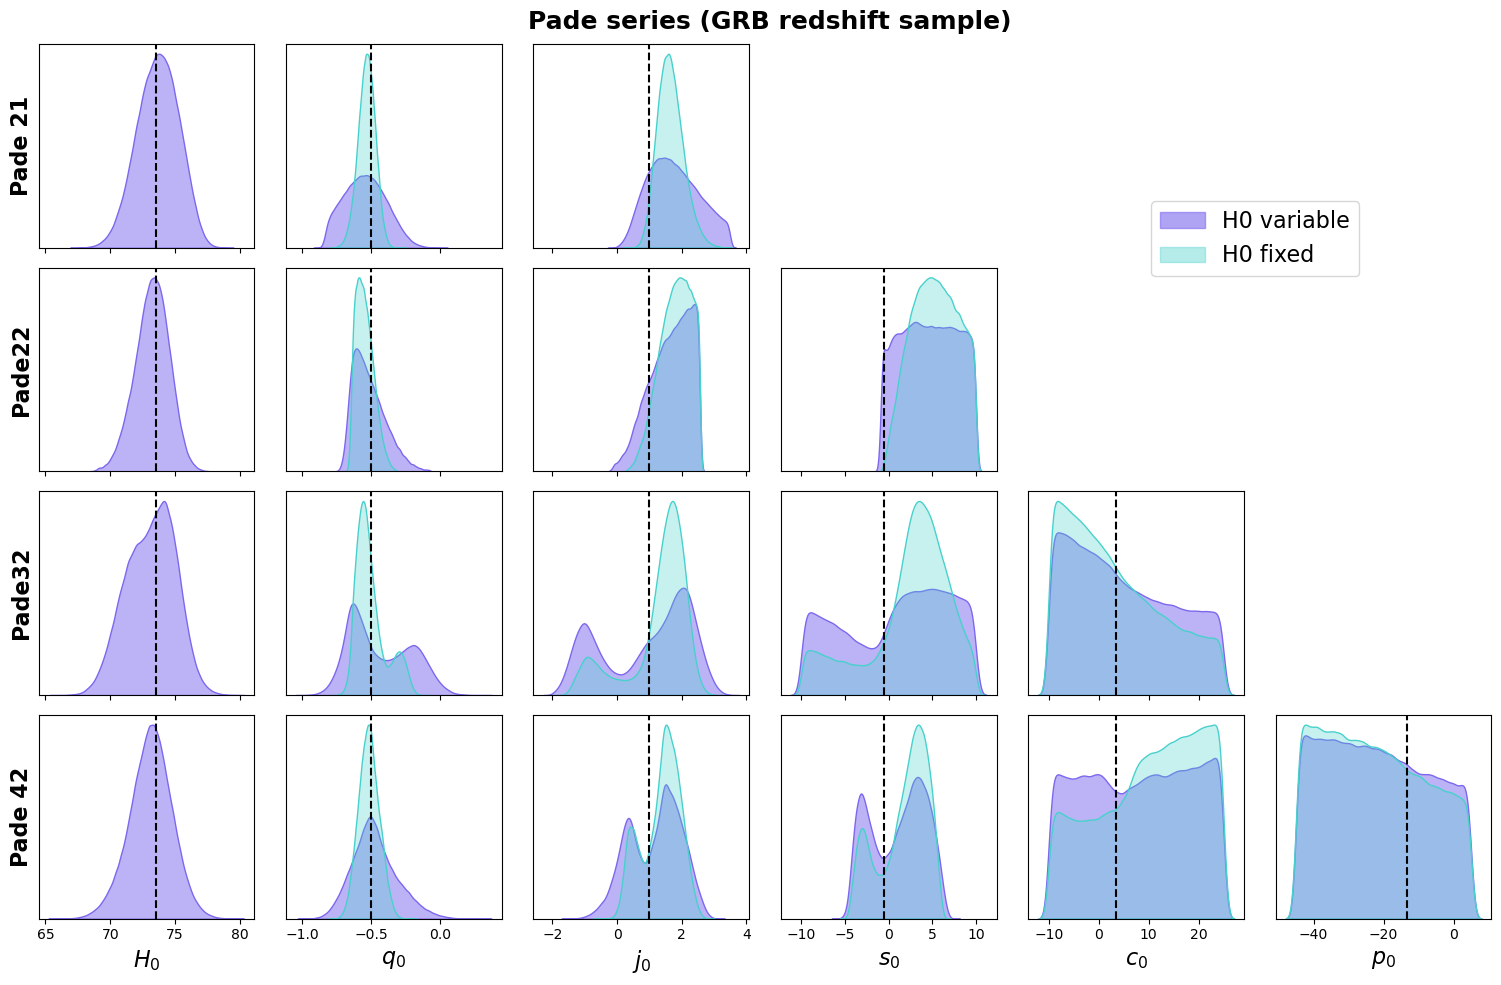

In [41]:
matrix_plot_posteriors2pade('Pade series', theta_true, sampler_pade, sampler_pade_noH)

# EIS

In [12]:
def matrix_plot_posteriors2eis(title, theta_true, sampler1, sampler2, ordermin=0):
    # Unpack true parameter values
    H0t, q0t, j0t, s0t, c0t, p0t = theta_true

    
    E1_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    E2_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    E3_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    E4_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    E5_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    
    H0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    q0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    j0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    s0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    c0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    p0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]

    for i in range(len(sampler1)):
        samples = sampler1[i].get_chain(discard=500, thin=10, flat=True)
        if len(samples[0])==2:
            H0_samples[i] = samples[:, 0]
            E1_samples[i] = samples[:, 1]
            q0_samples[i] = E1_samples[i] -1
        elif len(samples[0]) ==3:
            H0_samples[i] = samples[:, 0]
            E1_samples[i] = samples[:, 1]
            q0_samples[i] = E1_samples[i] -1
            
            E2_samples[i] = samples[:, 2]
            j0_samples[i] = E1_samples[i]**2 - 2*E1_samples[i] + E2_samples[i] + 1
        elif len(samples[0]) ==4:
            H0_samples[i] = samples[:, 0]
            E1_samples[i] = samples[:, 1]
            q0_samples[i] = E1_samples[i] -1
            
            E2_samples[i] = samples[:, 2]
            j0_samples[i] = E1_samples[i]**2 - 2*E1_samples[i] + E2_samples[i] + 1

            E3_samples[i] = samples[:, 3]
            s0_samples[i] = -E1_samples[i]**3 + 3*E1_samples[i]**2 - 4*E1_samples[i]*E2_samples[i] - 3*E1_samples[i] + E2_samples[i] - E3_samples[i] + 1
        elif len(samples[0]) ==5:
            H0_samples[i] = samples[:, 0]
            E1_samples[i] = samples[:, 1]
            q0_samples[i] = E1_samples[i] -1
            
            E2_samples[i] = samples[:, 2]
            j0_samples[i] = E1_samples[i]**2 - 2*E1_samples[i] + E2_samples[i] + 1
            
            E3_samples[i] = samples[:, 3]
            s0_samples[i] = -E1_samples[i]**3 + 3*E1_samples[i]**2 - 4*E1_samples[i]*E2_samples[i] - 3*E1_samples[i] + E2_samples[i] - E3_samples[i] + 1

            E4_samples[i] = samples[:, 4]
            c0_samples[i] = E1_samples[i]**4 - 4*E1_samples[i]**3 + 11*E1_samples[i]**2*E2_samples[i] + 6*E1_samples[i]**2 - E1_samples[i]*E2_samples[i] + 7*E1_samples[i]*E3_samples[i] - 4*E1_samples[i] + 4*E2_samples[i]**2 + 2*E2_samples[i] + E3_samples[i] + E4_samples[i] + 1
        else:
            H0_samples[i] = samples[:, 0]
            E1_samples[i] = samples[:, 1]
            q0_samples[i] = E1_samples[i] -1
            
            E2_samples[i] = samples[:, 2]
            j0_samples[i] = E1_samples[i]**2 - 2*E1_samples[i] + E2_samples[i] + 1
            
            E3_samples[i] = samples[:, 3]
            s0_samples[i] = -E1_samples[i]**3 + 3*E1_samples[i]**2 - 4*E1_samples[i]*E2_samples[i] - 3*E1_samples[i] + E2_samples[i] - E3_samples[i] + 1
            
            E4_samples[i] = samples[:, 4]
            c0_samples[i] = E1_samples[i]**4 - 4*E1_samples[i]**3 + 11*E1_samples[i]**2*E2_samples[i] + 6*E1_samples[i]**2 - E1_samples[i]*E2_samples[i] + 7*E1_samples[i]*E3_samples[i] - 4*E1_samples[i] + 4*E2_samples[i]**2 + 2*E2_samples[i] + E3_samples[i] + E4_samples[i] + 1

            E5_samples[i] = samples[:, 5]
            p0_samples[i] = -E1_samples[i]**5 + 5*E1_samples[i]**4 - 26*E1_samples[i]**3*E2_samples[i] - 10*E1_samples[i]**3 - 18*E1_samples[i]**2*E2_samples[i] - 32*E1_samples[i]**2*E3_samples[i] + 10*E1_samples[i]**2 - 34*E1_samples[i]*E2_samples[i]**2 - 18*E1_samples[i]*E2_samples[i] - 24*E1_samples[i]*E3_samples[i] - 11*E1_samples[i]*E4_samples[i] - 5*E1_samples[i] - 11*E2_samples[i]**2 - 15*E2_samples[i]*E3_samples[i] + 2*E2_samples[i] - 4*E3_samples[i] - 4*E4_samples[i] - E5_samples[i] + 1

    
    E1_samples2 = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    E2_samples2 = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    E3_samples2 = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    E4_samples2 = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    E5_samples2 = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]

    
    q0_samples2 = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    j0_samples2 = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    s0_samples2 = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    c0_samples2 = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    p0_samples2 = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]

    for i in range(len(sampler2)):
        samples2 = sampler2[i].get_chain(discard=500, thin=10, flat=True)
        if len(samples2[0])==1:
            #H0_samples[i] = samples[:, 0]
            E1_samples2[i] = samples2[:, 0]
            q0_samples2[i] = E1_samples2[i] -1
        elif len(samples2[0]) ==2:
            #H0_samples[i] = samples[:, 0]
            E1_samples2[i] = samples2[:, 0]
            q0_samples2[i] = E1_samples2[i] -1
            
            E2_samples2[i] = samples2[:, 1]
            j0_samples2[i] = E1_samples2[i]**2 - 2*E1_samples2[i] + E2_samples2[i] + 1
        elif len(samples2[0]) ==3:
            #H0_samples[i] = samples[:, 0]
            E1_samples2[i] = samples2[:, 0]
            q0_samples2[i] = E1_samples2[i] -1
            
            E2_samples2[i] = samples2[:, 1]
            j0_samples2[i] = E1_samples2[i]**2 - 2*E1_samples2[i] + E2_samples2[i] + 1

            E3_samples2[i] = samples2[:, 2]
            s0_samples2[i] = -E1_samples2[i]**3 + 3*E1_samples2[i]**2 - 4*E1_samples2[i]*E2_samples2[i] - 3*E1_samples2[i] + E2_samples2[i] - E3_samples2[i] + 1
        elif len(samples2[0]) ==4:
            #H0_samples[i] = samples[:, 0]
            E1_samples2[i] = samples2[:, 0]
            q0_samples2[i] = E1_samples2[i] -1
            
            E2_samples2[i] = samples2[:, 1]
            j0_samples2[i] = E1_samples2[i]**2 - 2*E1_samples2[i] + E2_samples2[i] + 1

            E3_samples2[i] = samples2[:, 2]
            s0_samples2[i] = -E1_samples2[i]**3 + 3*E1_samples2[i]**2 - 4*E1_samples2[i]*E2_samples2[i] - 3*E1_samples2[i] + E2_samples2[i] - E3_samples2[i] + 1

            E4_samples2[i] = samples2[:, 3]
            c0_samples2[i] = E1_samples2[i]**4 - 4*E1_samples2[i]**3 + 11*E1_samples2[i]**2*E2_samples2[i] + 6*E1_samples2[i]**2 - E1_samples2[i]*E2_samples2[i] + 7*E1_samples2[i]*E3_samples2[i] - 4*E1_samples2[i] + 4*E2_samples2[i]**2 + 2*E2_samples2[i] + E3_samples2[i] + E4_samples2[i] + 1
        else:
            #H0_samples[i] = samples[:, 0]
            E1_samples2[i] = samples2[:, 0]
            q0_samples2[i] = E1_samples2[i] -1
            
            E2_samples2[i] = samples2[:, 1]
            j0_samples2[i] = E1_samples2[i]**2 - 2*E1_samples2[i] + E2_samples2[i] + 1

            E3_samples2[i] = samples2[:, 2]
            s0_samples2[i] = -E1_samples2[i]**3 + 3*E1_samples2[i]**2 - 4*E1_samples2[i]*E2_samples2[i] - 3*E1_samples2[i] + E2_samples2[i] - E3_samples2[i] + 1

            E4_samples2[i] = samples2[:, 3]
            c0_samples2[i] = E1_samples2[i]**4 - 4*E1_samples2[i]**3 + 11*E1_samples2[i]**2*E2_samples2[i] + 6*E1_samples2[i]**2 - E1_samples2[i]*E2_samples2[i] + 7*E1_samples2[i]*E3_samples2[i] - 4*E1_samples2[i] + 4*E2_samples2[i]**2 + 2*E2_samples2[i] + E3_samples2[i] + E4_samples2[i] + 1

            E5_samples2[i] = samples2[:, 4]
            p0_samples2[i] = -E1_samples2[i]**5 + 5*E1_samples2[i]**4 - 26*E1_samples2[i]**3*E2_samples2[i] - 10*E1_samples2[i]**3 - 18*E1_samples2[i]**2*E2_samples2[i] - 32*E1_samples2[i]**2*E3_samples2[i] + 10*E1_samples2[i]**2 - 34*E1_samples2[i]*E2_samples2[i]**2 - 18*E1_samples2[i]*E2_samples2[i] - 24*E1_samples2[i]*E3_samples2[i] - 11*E1_samples2[i]*E4_samples2[i] - 5*E1_samples2[i] - 11*E2_samples2[i]**2 - 15*E2_samples2[i]*E3_samples2[i] + 2*E2_samples2[i] - 4*E3_samples2[i] - 4*E4_samples2[i] - E5_samples2[i] + 1


    # Number of columns (based on the ordermin parameter)
    order = len(sampler1) #5  -ordermin
    pars = 6
    
    # List of samples and true values for easy access
    samples_list = [H0_samples, q0_samples, j0_samples, s0_samples, c0_samples, p0_samples]
    samples_list2 = [[np.full(1,np.nan)], q0_samples2, j0_samples2, s0_samples2, c0_samples2, p0_samples2]
    true_values = [H0t, q0t, j0t, s0t, c0t, p0t]
    
    # Labels for the parameters
    param_labels = ['$H_0$', '$q_0$', '$j_0$', '$s_0$', '$c_0$', '$p_0$']
    order_labels = []
    for j in range(order):
        if title == 'Pade series':
            order_labels = ['Pade 21', 'Pade22', 'Pade32', 'Pade 42', 'Pade 51']
        else:
            order_labels.append('$\mathcal{O}(' + str(j+2+ordermin) + ')$')
       
    # Create the figure and axes for the matrix plot
    fig, axes = plt.subplots(order, pars, figsize=(15,10), sharex='col')
    # Set title for the entire figure
    fig.suptitle(f'{title} (GRB redshift sample)', fontsize=18, weight='bold')
    gs = gridspec.GridSpec(order, pars)

    # Loop through the grid and plot KDEs
    for i in range(order):
        for j in range(pars):
            ax = axes[ i,j]

            # Get the posterior samples and true value for the current parameter
            if ~np.isnan(samples_list[j][i][0]):  # Make sure there are samples
                samples = samples_list[j][i]
                true_val = true_values[j]

                if len(samples) > 0:  # Plot KDE only if samples exist
                    sns.kdeplot(samples, fill=True, ax=ax, alpha=0.5, legend=False, color= 'mediumslateblue')
                    plt.ylabel('')
                    # Plot the true value line
                    ax.axvline(true_val, color='black', linestyle='--')
                    if j == 0:
                        ax.set_ylabel(order_labels[i], fontsize=16, weight='bold')
                    else:
                        ax.set_ylabel('')

                # Remove density ylabel
            ax.set_yticks([])
            
            # Turn off empty cells
            if np.isnan(samples_list[j][i][0]):
                ax.axis('off')

            # Add parameter labels on the left side
            if i == order - 1:
                ax.set_xlabel(param_labels[j], fontsize=16, weight='bold')
                        
    for i in range(order):
        for j in range(pars-1):
            ax = axes[i, j+1]
            if ~np.isnan(samples_list2[j+1][i][0]):
                samples2 = samples_list2[j+1][i]#if i < len(samples_list[j]) else []
                if len(samples2) > 0:  # Plot KDE only if samples exist
                    sns.kdeplot(samples2, fill=True, ax=ax, alpha=0.3, legend=False, color= 'mediumturquoise')

    # Define the color boxes for the legend with matching alpha and colors
    sample1_patch = mpatches.Patch(color='mediumslateblue', alpha=0.6, label='H0 variable')
    sample2_patch = mpatches.Patch(color='mediumturquoise', alpha=0.4, label='H0 fixed')

    # Add the legend to the figure manually (place it in the top right corner)
    fig.legend(handles=[sample1_patch, sample2_patch], loc='upper right', bbox_to_anchor=(0.9, 0.8), fontsize=16)

    # Adjust layout to eliminate space between subplots
    plt.subplots_adjust(wspace=-4, hspace=-1)  # Remove horizontal/vertical spaces

    # Adjust layout to avoid overlap
    plt.tight_layout()
    plt.savefig(f'Posteriors_matrix_{title}_GRB_comparison.png', dpi=500,  bbox_inches='tight')  # To save as PNG

    # Show the plot
    plt.show()

<>:156: SyntaxWarning: invalid escape sequence '\m'
<>:156: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_7453/4087889980.py:156: SyntaxWarning: invalid escape sequence '\m'
  order_labels.append('$\mathcal{O}(' + str(j+2+ordermin) + ')$')


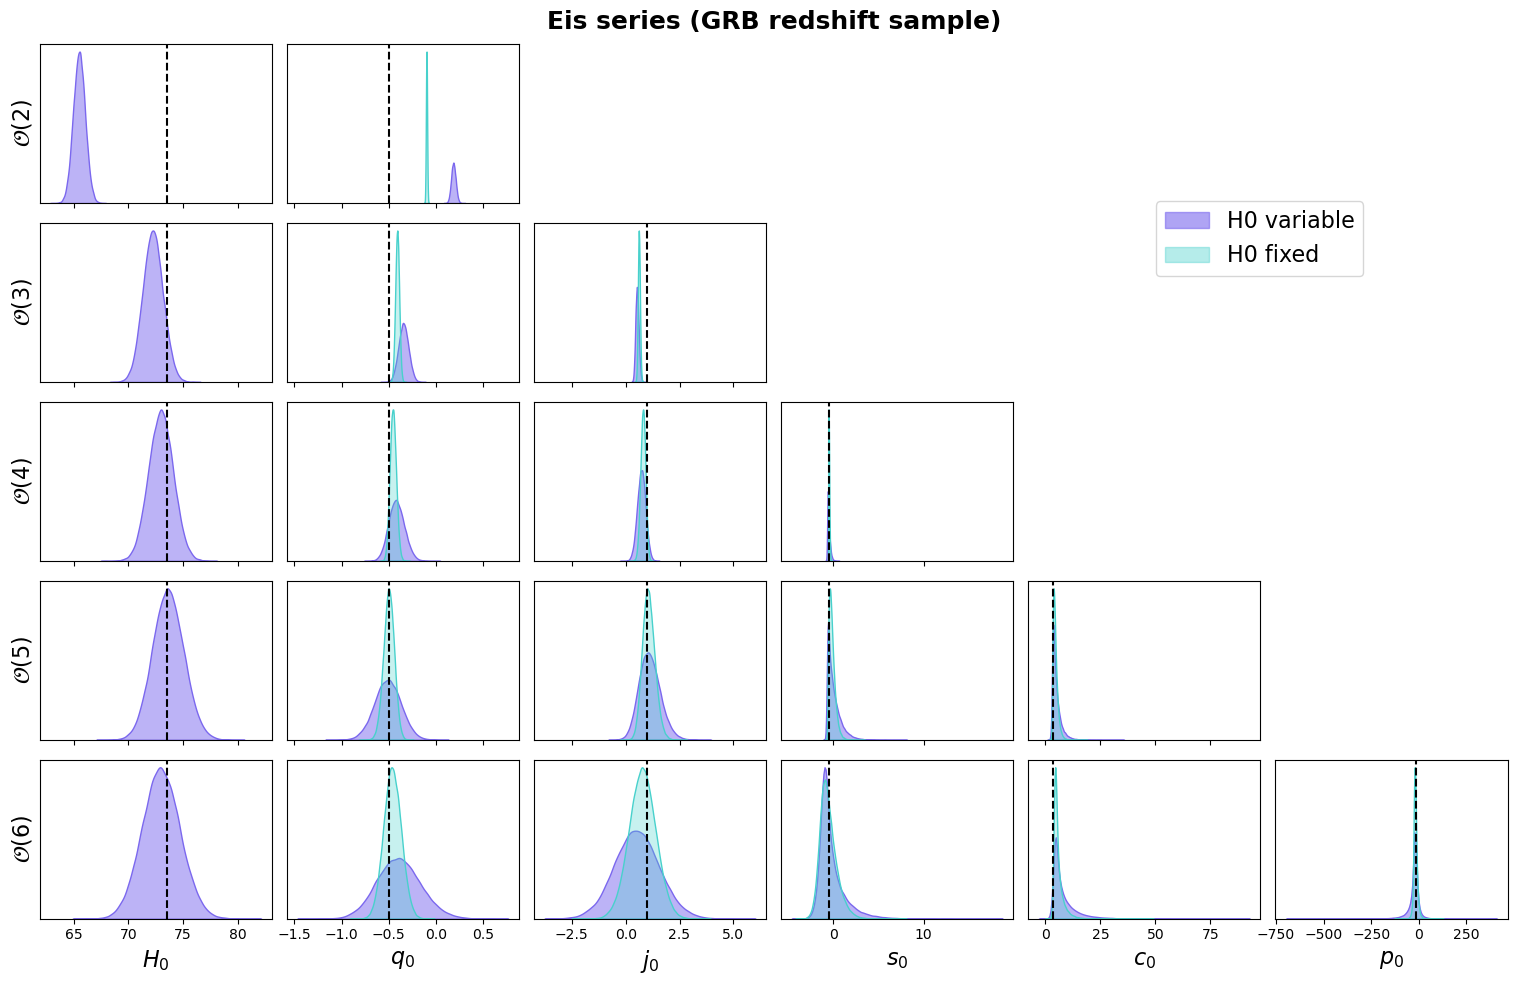

In [13]:
matrix_plot_posteriors2eis("Eis series", theta_true, sampler_eis, sampler_eis_noH, ordermin=0)

# Ext vs GRB

In [65]:
import matplotlib.gridspec as gridspec
#from matplotlib.lines import Line2D 
import matplotlib.patches as mpatches  

def matrix_plot_posteriors_ext(title, theta_true, sampler1, sampler2, ordermin=0):
    # Unpack true parameter values
    H0t, q0t, j0t, s0t, c0t, p0t = theta_true

    H0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    q0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    j0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    s0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    c0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    p0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]

    for i in range(len(sampler1)):
        samples = sampler1[i].get_chain(discard=500, thin=10, flat=True)
        if len(samples[0])==2:
            H0_samples[i] = samples[:, 0]
            q0_samples[i] = samples[:, 1]
        elif len(samples[0]) ==3:
            H0_samples[i] = samples[:, 0]
            q0_samples[i] = samples[:, 1]
            j0_samples[i] = samples[:, 2]
        elif len(samples[0]) ==4:
            H0_samples[i] = samples[:, 0]
            q0_samples[i] = samples[:, 1]
            j0_samples[i] = samples[:, 2]
            s0_samples[i] = samples[:, 3]
        elif len(samples[0]) ==5:
            H0_samples[i] = samples[:, 0]
            q0_samples[i] = samples[:, 1]
            j0_samples[i] = samples[:, 2]
            s0_samples[i] = samples[:, 3]
            c0_samples[i] = samples[:, 4]
        else:
            H0_samples[i] = samples[:, 0]
            q0_samples[i] = samples[:, 1]
            j0_samples[i] = samples[:, 2]
            s0_samples[i] = samples[:, 3]
            c0_samples[i] = samples[:, 4]
            p0_samples[i] = samples[:, 5]

    H0_samples2 = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    q0_samples2 = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    j0_samples2 = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    s0_samples2 = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    c0_samples2 = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    p0_samples2 = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]

    for i in range(len(sampler2)):
        samples2 = sampler2[i].get_chain(discard=500, thin=10, flat=True)
        if len(samples2[0])==2:
            H0_samples2[i] = samples2[:, 0]
            q0_samples2[i] = samples2[:, 1]
        elif len(samples2[0]) ==3:
            H0_samples2[i] = samples2[:, 0]
            q0_samples2[i] = samples2[:, 1]
            j0_samples2[i] = samples2[:, 2]
        elif len(samples2[0]) ==4:
            H0_samples2[i] = samples2[:, 0]
            q0_samples2[i] = samples2[:, 1]
            j0_samples2[i] = samples2[:, 2]
            s0_samples2[i] = samples2[:, 3]
        elif len(samples2[0]) ==5:
            H0_samples2[i] = samples2[:, 0]
            q0_samples2[i] = samples2[:, 1]
            j0_samples2[i] = samples2[:, 2]
            s0_samples2[i] = samples2[:, 3]
            c0_samples2[i] = samples2[:, 4]
        else:
            H0_samples2[i] = samples2[:, 0]
            q0_samples2[i] = samples2[:, 1]
            j0_samples2[i] = samples2[:, 2]
            s0_samples2[i] = samples2[:, 3]
            c0_samples2[i] = samples2[:, 4]
            p0_samples2[i] = samples2[:, 5]
   

    # Number of columns (based on the ordermin parameter)
    order = len(sampler1) #5  -ordermin
    pars = 6
    
    # List of samples and true values for easy access
    samples_list = [H0_samples, q0_samples, j0_samples, s0_samples, c0_samples, p0_samples]
    samples_list2 = [H0_samples2, q0_samples2, j0_samples2, s0_samples2, c0_samples2, p0_samples2]
    true_values = [H0t, q0t, j0t, s0t, c0t, p0t]
    
    # Labels for the parameters
    param_labels = ['$H_0$', '$q_0$', '$j_0$', '$s_0$', '$c_0$', '$p_0$']
    order_labels = []
    for j in range(order):
        if title == 'Pade series':
            order_labels = ['Pade 21', 'Pade22', 'Pade32', 'Pade 42']
        else:
            order_labels.append('$\mathcal{O}(' + str(j+2+ordermin) + ')$')
    
    # Create the figure and axes for the matrix plot
    fig, axes = plt.subplots(order, pars, figsize=(15,10), sharex='col')
    # Set title for the entire figure
    fig.suptitle(f'{title} (GRB samples comparison)', fontsize=18, weight='bold')
    gs = gridspec.GridSpec(order, pars)

    # Loop through the grid and plot KDEs
    for i in range(order):
        for j in range(pars):
            ax = axes[ i,j]

            # Get the posterior samples and true value for the current parameter
            if ~np.isnan(samples_list[j][i][0]):  # Make sure there are samples
                samples = samples_list[j][i]
                samples2 = samples_list2[j][i]
                true_val = true_values[j]

                if len(samples) > 0:  # Plot KDE only if samples exist
                    sns.kdeplot(samples, fill=True, ax=ax, alpha=0.5, legend=False, color= 'mediumslateblue')
                    sns.kdeplot(samples2, fill=True, ax=ax, alpha=0.3, legend=False, color= 'mediumturquoise')
                    plt.ylabel('')
                    # Plot the true value line
                    ax.axvline(true_val, color='black', linestyle='--')
                    if j == 0:
                        ax.set_ylabel(order_labels[i], fontsize=16, weight='bold')
                    else:
                        ax.set_ylabel('')

                # Remove density ylabel
            ax.set_yticks([])
            
            # Turn off empty cells
            if np.isnan(samples_list[j][i][0]):
                ax.axis('off')

            # Add parameter labels on the left side
            if i == order - 1:
                ax.set_xlabel(param_labels[j], fontsize=16, weight='bold')
                        
    
    #  # Add legend on the top right corner
    # custom_lines = [Line2D([0], [0], color='mediumslateblue', lw=4, label='H0 as variable'),
    #                 Line2D([0], [0], color='mediumturquoise', lw=4, label='H0 fixed')]
    
    # fig.legend(handles=custom_lines, loc='upper right', fontsize=16)

    # Define the color boxes for the legend with matching alpha and colors
    sample1_patch = mpatches.Patch(color='mediumslateblue', alpha=0.6, label='GRB 579 sample')
    sample2_patch = mpatches.Patch(color='mediumturquoise', alpha=0.4, label='GRB extended mock sample')

    # Add the legend to the figure manually (place it in the top right corner)
    fig.legend(handles=[sample1_patch, sample2_patch], loc='upper right', bbox_to_anchor=(0.9, 0.8), fontsize=16)

    # Adjust layout to eliminate space between subplots
    plt.subplots_adjust(wspace=-4, hspace=-1)  # Remove horizontal/vertical spaces

    # Adjust layout to avoid overlap
    plt.tight_layout()
    plt.savefig(f'Posteriors_matrix_{title}_GRB_extvsnormal_comparison.png', dpi=500,  bbox_inches='tight')  # To save as PNG

    # Show the plot
    plt.show()

<>:96: SyntaxWarning: invalid escape sequence '\m'
<>:96: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_16094/1964845612.py:96: SyntaxWarning: invalid escape sequence '\m'
  order_labels.append('$\mathcal{O}(' + str(j+2+ordermin) + ')$')


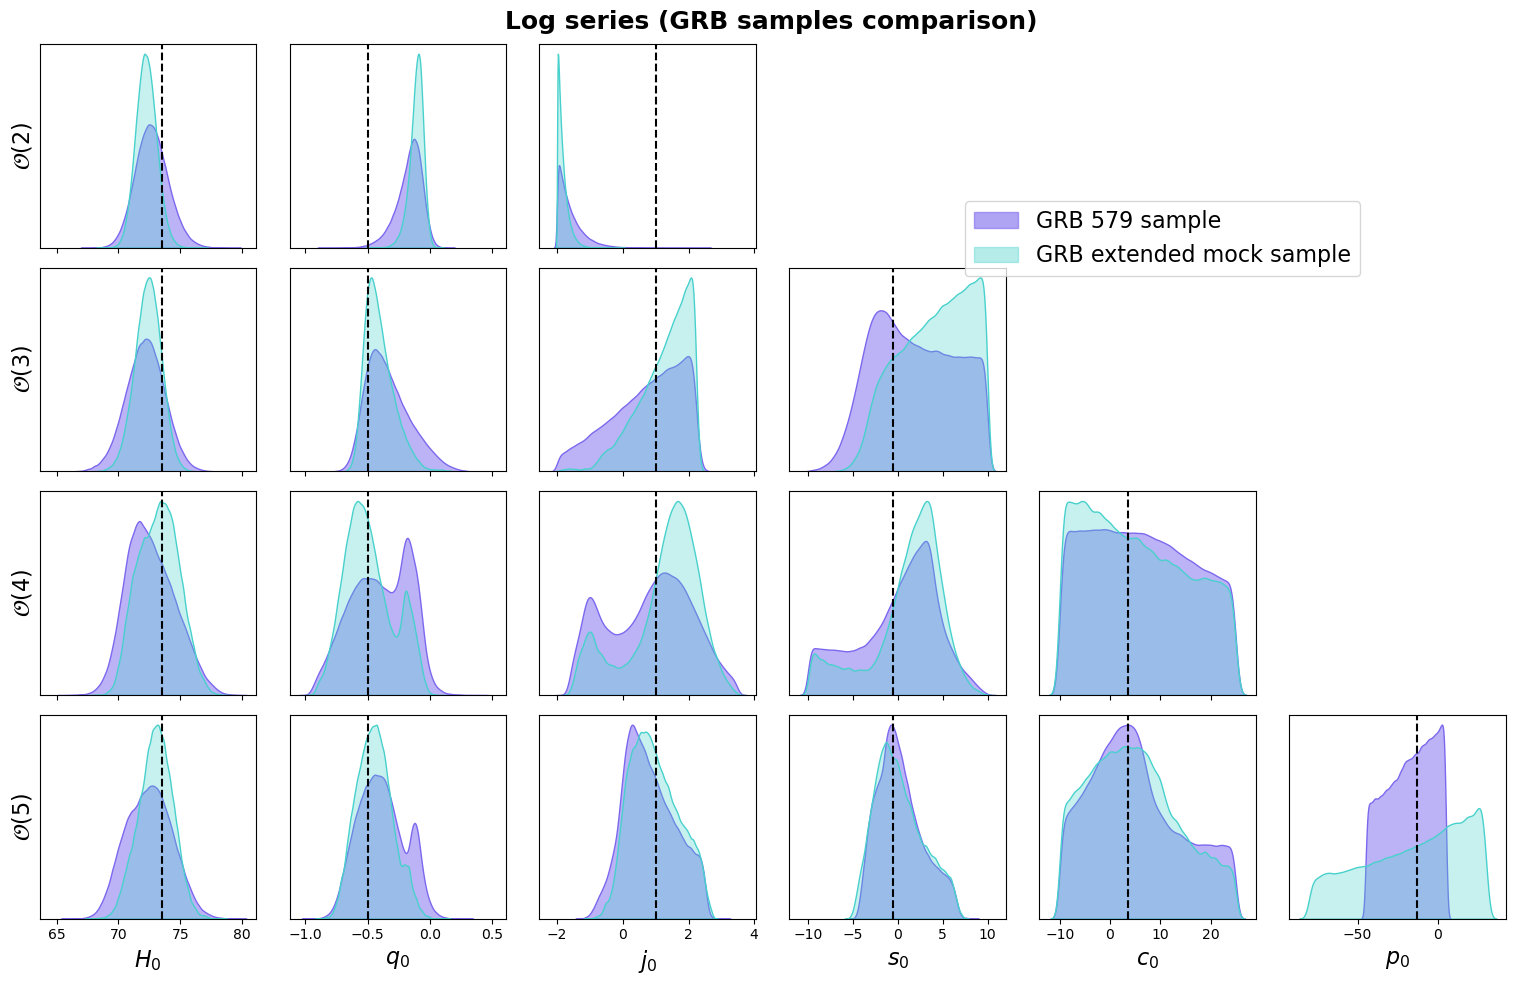

In [57]:
matrix_plot_posteriors_ext('Log series', theta_true, sampler_order_log, sampler_order_log_ext, ordermin=0)

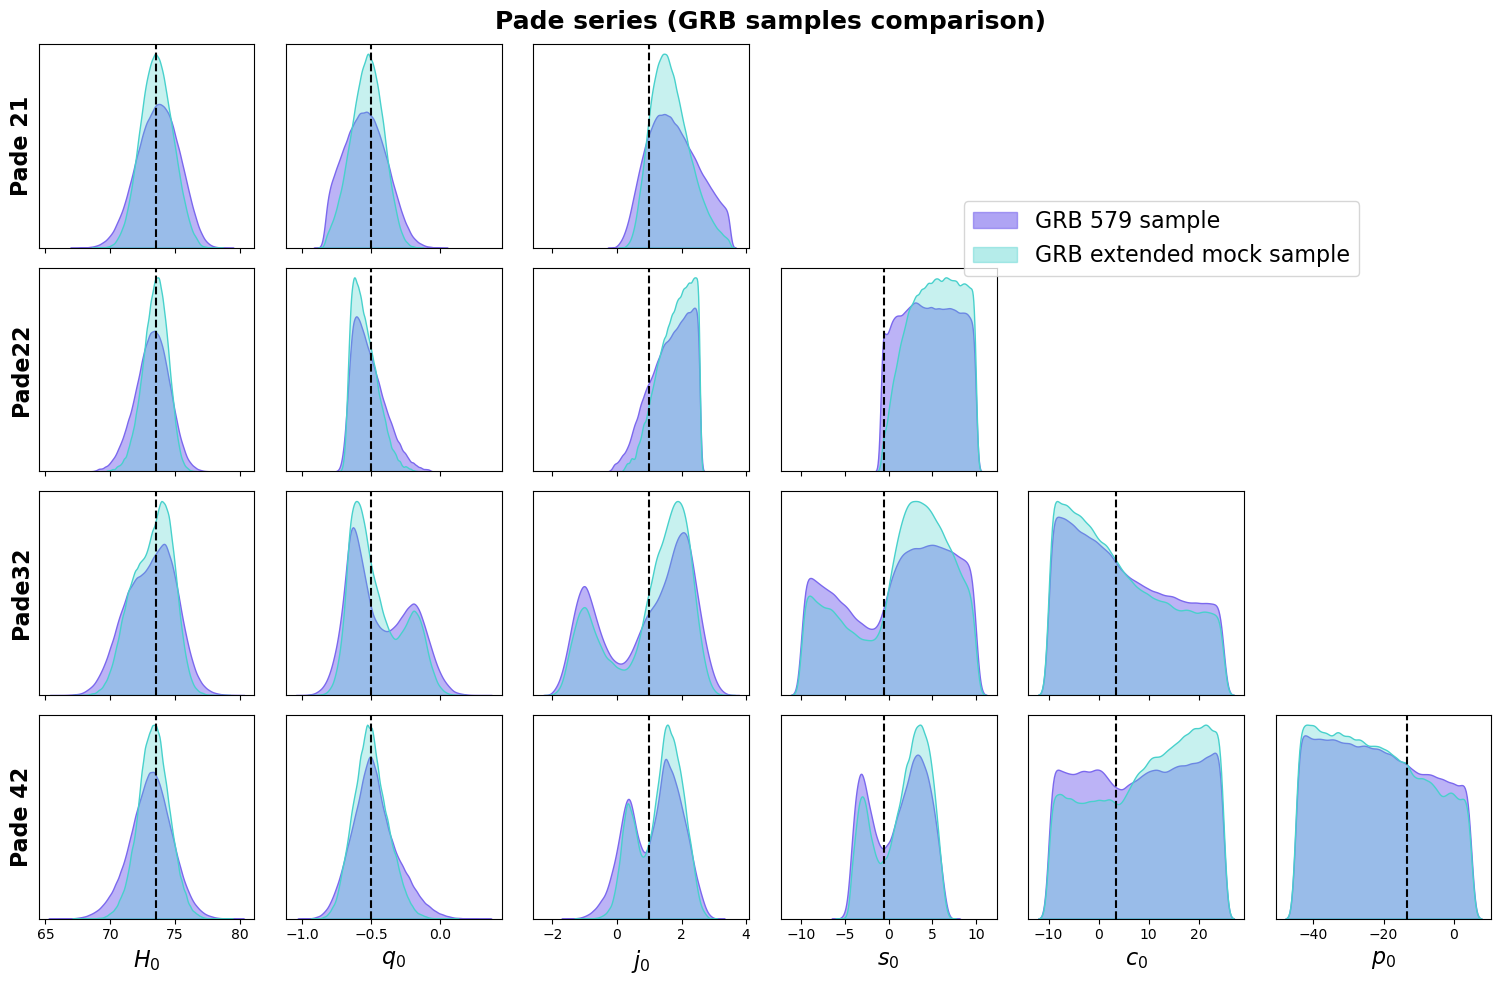

In [67]:
matrix_plot_posteriors_ext('Pade series', theta_true, sampler_pade, sampler_pade_ext, ordermin=0)

# Extras

In [ ]:
# # def matrix_plot_posteriors(title, theta_true, sampler, ordermin=0):
# #     # Unpack true parameter values
# #     H0t, q0t, j0t, s0t, c0t, p0t = theta_true

# #     H0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
# #     q0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
# #     j0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
# #     s0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
# #     c0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
# #     p0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]

# #     for i in range(len(sampler_order_log)):
# #         samples = sampler_order_log[i].get_chain(discard=500, thin=10, flat=True)
# #         if len(samples[0])==2:
# #             H0_samples[i] = samples[:, 0]
# #             q0_samples[i] = samples[:, 1]
# #         elif len(samples[0]) ==3:
# #             H0_samples[i] = samples[:, 0]
# #             q0_samples[i] = samples[:, 1]
# #             j0_samples[i] = samples[:, 2]
# #         elif len(samples[0]) ==4:
# #             H0_samples[i] = samples[:, 0]
# #             q0_samples[i] = samples[:, 1]
# #             j0_samples[i] = samples[:, 2]
# #             s0_samples[i] = samples[:, 3]
# #         elif len(samples[0]) ==5:
# #             H0_samples[i] = samples[:, 0]
# #             q0_samples[i] = samples[:, 1]
# #             j0_samples[i] = samples[:, 2]
# #             s0_samples[i] = samples[:, 3]
# #             c0_samples[i] = samples[:, 4]
# #         else:
# #             H0_samples[i] = samples[:, 0]
# #             q0_samples[i] = samples[:, 1]
# #             j0_samples[i] = samples[:, 2]
# #             s0_samples[i] = samples[:, 3]
# #             c0_samples[i] = samples[:, 4]
# #             p0_samples[i] = samples[:, 5]

# #     # Number of columns (based on the ordermin parameter)
# #     order = 5  
# #     pars = 6
    
# #     # List of samples and true values for easy access
# #     samples_list = [H0_samples, q0_samples, j0_samples, s0_samples, c0_samples, p0_samples]
# #     true_values = [H0t, q0t, j0t, s0t, c0t, p0t]
    
# #     # Labels for the parameters
# #     param_labels = ['$H_0$', '$q_0$', '$j_0$', '$s_0$', '$c_0$', '$p_0$']
# #     order_labels = []
# #     for j in range(order):
# #         order_labels.append('$\mathcal{O}(' + str(j+2) + ')$')
    
# #     # Create the figure and axes for the matrix plot
# #     fig, axes = plt.subplots( order,pars, figsize=(10, 10))

# #     # Set title for the entire figure
# #     fig.suptitle('MCMC Posterior Distributions', fontsize=16)

# #     # Loop through the grid and plot KDEs
# #     for i in range(order):
# #         for j in range(pars):
# #             ax = axes[i,j]

# #             # Get the posterior samples and true value for the current parameter
# #             if ~np.isnan(samples_list[j][i][0]):  # Make sure there are samples
# #                 samples = samples_list[j][i] #if i < len(samples_list[j]) else []
# #                 true_val = true_values[j]

# #                 if len(samples) > 0:  # Plot KDE only if samples exist
# #                     sns.kdeplot(samples, fill=True, ax=ax, alpha=0.5, legend=False)
# #                     plt.ylabel('')
# #                     # Plot the true value line
# #                     ax.axvline(true_val, color='black', linestyle='--')
# #                     if j==0:
# #                         #ax.set_title(order_labels[i], fontsize=12)
# #                         ax.set_ylabel(order_labels[i], fontsize=12)
# #                     else:
# #                         ax.set_ylabel('')


# #             # Remove density ylabel
# #             ax.set_yticks([])
            
# #             # Turn off empty cells
# #             if np.isnan(samples_list[j][i][0]):
# #                 ax.axis('off')

# #             # Add parameter labels on the left side
# #             if i == 4:
# #                 #ax.yaxis.set_label_position("right")
# #                 ax.set_xlabel(param_labels[j], fontsize=12)
            


# #     # Adjust layout to eliminate space between subplots
# #     plt.subplots_adjust(wspace=-4, hspace=-1)  # Remove horizontal/vertical spaces

# #     # Adjust layout to avoid overlap
# #     plt.tight_layout()
    
# #     # Show the plot
# #     plt.show()


# def matrix_plot_posteriors(title, theta_true, sampler, ordermin=0):
#     # Unpack true parameter values
#     H0t, q0t, j0t, s0t, c0t, p0t = theta_true

#     H0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
#     q0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
#     j0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
#     s0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
#     c0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
#     p0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]

#     for i in range(len(sampler_order_log)):
#         samples = sampler_order_log[i].get_chain(discard=500, thin=10, flat=True)
#         if len(samples[0])==2:
#             H0_samples[i] = samples[:, 0]
#             q0_samples[i] = samples[:, 1]
#         elif len(samples[0]) ==3:
#             H0_samples[i] = samples[:, 0]
#             q0_samples[i] = samples[:, 1]
#             j0_samples[i] = samples[:, 2]
#         elif len(samples[0]) ==4:
#             H0_samples[i] = samples[:, 0]
#             q0_samples[i] = samples[:, 1]
#             j0_samples[i] = samples[:, 2]
#             s0_samples[i] = samples[:, 3]
#         elif len(samples[0]) ==5:
#             H0_samples[i] = samples[:, 0]
#             q0_samples[i] = samples[:, 1]
#             j0_samples[i] = samples[:, 2]
#             s0_samples[i] = samples[:, 3]
#             c0_samples[i] = samples[:, 4]
#         else:
#             H0_samples[i] = samples[:, 0]
#             q0_samples[i] = samples[:, 1]
#             j0_samples[i] = samples[:, 2]
#             s0_samples[i] = samples[:, 3]
#             c0_samples[i] = samples[:, 4]
#             p0_samples[i] = samples[:, 5]

#     # Number of columns (based on the ordermin parameter)
#     order = 5  
#     pars = 6
    
#     # List of samples and true values for easy access
#     samples_list = [H0_samples, q0_samples, j0_samples, s0_samples, c0_samples, p0_samples]
#     true_values = [H0t, q0t, j0t, s0t, c0t, p0t]
    
#     # Labels for the parameters
#     param_labels = ['$H_0$', '$q_0$', '$j_0$', '$s_0$', '$c_0$', '$p_0$']
#     order_labels = []
#     for j in range(order):
#         order_labels.append('$\mathcal{O}(' + str(j+2) + ')$')
    
#     # Create the figure and axes for the matrix plot
#     fig, axes = plt.subplots(order, pars, figsize=(10, 10), sharex='col')  # Added sharex='col'

#     # Set title for the entire figure
#     fig.suptitle('MCMC Posterior Distributions', fontsize=16)

#     # Loop through the grid and plot KDEs
#     for i in range(order):
#         for j in range(pars):
#             ax = axes[i, j]

#             # Get the posterior samples and true value for the current parameter
#             if ~np.isnan(samples_list[j][i][0]):  # Make sure there are samples
#                 samples = samples_list[j][i] # if i < len(samples_list[j]) else []
#                 true_val = true_values[j]

#                 if len(samples) > 0:  # Plot KDE only if samples exist
#                     sns.kdeplot(samples, fill=True, ax=ax, alpha=0.5, legend=False)
#                     plt.ylabel('')
#                     # Plot the true value line
#                     ax.axvline(true_val, color='black', linestyle='--')
#                     if j == 0:
#                         ax.set_ylabel(order_labels[i], fontsize=12)
#                     else:
#                         ax.set_ylabel('')

#             # Remove density ylabel
#             ax.set_yticks([])

#             # Turn off empty cells
#             if np.isnan(samples_list[j][i][0]):
#                 ax.axis('off')

#             # Add parameter labels on the bottom row
#             if i == order - 1:
#                 ax.set_xlabel(param_labels[j], fontsize=12)

#     # Adjust layout to eliminate space between subplots
#     plt.subplots_adjust(wspace=0, hspace=0)  # Adjusted to remove spacing

#     # Adjust layout to avoid overlap
#     plt.tight_layout()

#     # Show the plot
#     plt.show()


In [ ]:
from matplotlib.ticker import StrMethodFormatter

def matrix_plot_posteriors2(title, theta_true, sampler, ordermin=0):
    # Unpack true parameter values
    H0t, q0t, j0t, s0t, c0t, p0t = theta_true

    H0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    q0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    j0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    s0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    c0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    p0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]

    for i in range(len(sampler_order_log)):
        samples = sampler_order_log[i].get_chain(discard=500, thin=10, flat=True)
        if len(samples[0])==2:
            H0_samples[i] = samples[:, 0]
            q0_samples[i] = samples[:, 1]
        elif len(samples[0]) ==3:
            H0_samples[i] = samples[:, 0]
            q0_samples[i] = samples[:, 1]
            j0_samples[i] = samples[:, 2]
        elif len(samples[0]) ==4:
            H0_samples[i] = samples[:, 0]
            q0_samples[i] = samples[:, 1]
            j0_samples[i] = samples[:, 2]
            s0_samples[i] = samples[:, 3]
        elif len(samples[0]) ==5:
            H0_samples[i] = samples[:, 0]
            q0_samples[i] = samples[:, 1]
            j0_samples[i] = samples[:, 2]
            s0_samples[i] = samples[:, 3]
            c0_samples[i] = samples[:, 4]
        else:
            H0_samples[i] = samples[:, 0]
            q0_samples[i] = samples[:, 1]
            j0_samples[i] = samples[:, 2]
            s0_samples[i] = samples[:, 3]
            c0_samples[i] = samples[:, 4]
            p0_samples[i] = samples[:, 5]

    # Number of columns (based on the ordermin parameter)
    order = 5  
    pars = 6
    
    # List of samples and true values for easy access
    samples_list = [H0_samples, q0_samples, j0_samples, s0_samples, c0_samples, p0_samples]
    true_values = [H0t, q0t, j0t, s0t, c0t, p0t]
    
    # Labels for the parameters
    param_labels = ['$H_0$', '$q_0$', '$j_0$', '$s_0$', '$c_0$', '$p_0$']
    order_labels = []
    for j in range(order):
        order_labels.append('$\mathcal{O}(' + str(j+2) + ')$')
    
    # Create the figure and axes for the matrix plot
    fig, axes = plt.subplots(order, pars, figsize=(10, 8))

    # Set title for the entire figure
    fig.suptitle('MCMC Posterior Distributions', fontsize=16)

    # Loop through the grid and plot KDEs
    for i in range(order):
        for j in range(pars):
            ax = axes[i, j]

            # Get the posterior samples and true value for the current parameter
            if ~np.isnan(samples_list[j][i][0]):  # Make sure there are samples
                samples = samples_list[j][i] #if i < len(samples_list[j]) else []
                true_val = true_values[j]

                if len(samples) > 0:  # Plot KDE only if samples exist
                    sns.despine()
                    sns.kdeplot(samples, fill=True, ax=ax, alpha=0.5, legend=False)
                    plt.ylabel('')
                    # Plot the true value line
                    ax.axvline(true_val, color='black', linestyle='--')
                    #plt.tick_params(axis='both', which='major', labelsize=8)
                    # plt.xticks(fontsize=4)
                    # plt.yticks(fontsize=4)


            # Turn off empty cells
            if np.isnan(samples_list[j][i][0]):
                ax.axis('off')

            # Add parameter labels on the left side
            if i == 4:
                ax.set_xlabel(param_labels[j], fontsize=12)
            else:
                ax.set_xlabel('')
                plt.xticks([])
                plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}')) # No decimal places
            # Add order labels on the bottom
            if j == 0:
                ax.set_ylabel(order_labels[i], fontsize=12)
            else:
                ax.set_ylabel('')
                ax.set_yticks([])

    # Adjust layout to eliminate space between subplots
    plt.subplots_adjust(wspace=-4, hspace=-1)  # Remove horizontal/vertical spaces

    # Adjust layout to avoid overlap
    plt.tight_layout()
    #plt.subplots_adjust(top=0.5)  # Leave space for the title
    
    # Show the plot
    plt.show()

In [ ]:
matrix_plot_posteriors2('MCMC Posterior Distributions', theta_truue, sampler_order_log, ordermin=0)

In [355]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
data_list =[]
df_list = []
def matrix_plot_posteriors_facetgrid(title, theta_true, sampler, ordermin=0):
    # Unpack true parameter values
    H0t, q0t, j0t, s0t, c0t, p0t = theta_true

    H0_samples = [np.full(1, np.nan)] * 5
    q0_samples = [np.full(1, np.nan)] * 5
    j0_samples = [np.full(1, np.nan)] * 5
    s0_samples = [np.full(1, np.nan)] * 5
    c0_samples = [np.full(1, np.nan)] * 5
    p0_samples = [np.full(1, np.nan)] * 5

    for i in range(len(sampler)):
        samples = sampler[i].get_chain(discard=500, thin=10, flat=True)
        if len(samples[0]) == 2:
            H0_samples[i], q0_samples[i] = samples[:, 0], samples[:, 1]
        elif len(samples[0]) == 3:
            H0_samples[i], q0_samples[i], j0_samples[i] = samples[:, 0], samples[:, 1], samples[:, 2]
        elif len(samples[0]) == 4:
            H0_samples[i], q0_samples[i], j0_samples[i], s0_samples[i] = samples[:, 0], samples[:, 1], samples[:, 2], samples[:, 3]
        elif len(samples[0]) == 5:
            H0_samples[i], q0_samples[i], j0_samples[i], s0_samples[i], c0_samples[i] = samples[:, 0], samples[:, 1], samples[:, 2], samples[:, 3], samples[:, 4]
        else:
            H0_samples[i], q0_samples[i], j0_samples[i], s0_samples[i], c0_samples[i], p0_samples[i] = samples[:, 0], samples[:, 1], samples[:, 2], samples[:, 3], samples[:, 4], samples[:, 5]

    # List of samples and true values for easy access
    samples_list = [H0_samples, q0_samples, j0_samples, s0_samples, c0_samples, p0_samples]
    param_labels = ['$H_0$', '$q_0$', '$j_0$', '$s_0$', '$c_0$', '$p_0$']
    order = 5  
    order_labels = []
    for j in range(order):
        order_labels.append('$\mathcal{O}(' + str(j+2) + ')$')

    # Combine the samples into a long DataFrame
    data = []
    for param_idx, samples in enumerate(samples_list):
        for order_idx, order_samples in enumerate(samples):
            if not np.isnan(order_samples[0]):  # Only add valid samples
                for sample in order_samples:
                    data.append([sample, param_labels[param_idx], order_labels[order_idx]])
    
    # Create the DataFrame
    df = pd.DataFrame(data, columns=['Value', 'Parameter', 'Order'])
    data_list.append(data)
    data_list.append(df)

    # True values for vertical lines
    # true_values = {param_labels[i]: val for i, val in enumerate(theta_true)}

    # Create the FacetGrid with rows as parameters and columns as orders
    g = sns.FacetGrid(df, row="Parameter", col="Order", sharex=False, sharey=False, aspect=1, margin_titles=True)

    # Plot KDEs in each facet
    g.map(sns.kdeplot, "Value", fill=True, alpha=0.5)

    # for ax, (row_val, col_val) in zip(g.axes.flat, g.facet_data()):
    # #for ax, (row_val, col_val) in enumerate(zip(g.axes.flat,  g.facet_data())):
    #     # Extract the parameter index (row) and order index (column)

    #     param = row_val[0]  # Get the parameter from row_val
    #     #print(col_val['Order'])#, len(col_val))

    #     for k in range(len(col_val['Order'])):
    #         if col_val['Order'].iloc[0][k] == '$\mathcal{O}(2)$':
    #             print('hey yo')

        # param_idx = row_val[0]  # Assuming row_val is a tuple like (0, 0, 0)
        # order_idx = col_val[0]  # Adjust index extraction based on the actual structure
    
        # param = param_labels[param_idx]  # Get the parameter label
        # order = order_labels[order_idx]  # Get the order label
    
        # # Check if the DataFrame has valid samples for the current parameter and order
        # filtered_samples = df[(df['Parameter'] == param) & (df['Order'] == order)]
    
        # # Turn off the axis if no valid samples
        # if filtered_samples.empty:
        #     ax.set_axis_off()
        # else:
        #     true_val = true_values.get(param, None)
        #     if true_val is not None:
        #         ax.axvline(true_val, color='red', linestyle='--')

    
    # # Loop over the grid axes and customize the plot
    # for ax, (row_val, col_val) in zip(g.axes.flat, g.facet_data()):
    #     param = row_val  # Use row_val directly as the parameter label
    #     order = col_val  # Use col_val directly as the order label
        
    #     # Find the true value for the current parameter
    #     true_val = true_values.get(param, None)
        
    #     # Get the posterior samples for the current subplot (use param and order as needed)
    #     if true_val is not None:
    #         ax.axvline(true_val, color='black', linestyle='--')
    
    #     # Turn off the axis if no valid samples
    #     #samples = df[(df['Parameter'] == param) & (df['Order'] == order)]
    #     # Extract the correct strings for the parameter and order
    #     param_str = str(param)
    #     order_str = str(order)
    #     print(param, order)

    #     # Check if the DataFrame has valid samples for the current parameter and order
    #     filtered_samples = df[(df['Parameter'] == param_str) & (df['Order'] == order_str)]

    #     # Turn off the axis if no valid samples
    #     if filtered_samples.empty:
    #         ax.set_axis_off()

    # for ax, (row_val, col_val) in zip(g.axes.flat, g.facet_data()):
    #     param = row_val[0]  # Extract the parameter (row label)
    #     order = col_val[0]  # Extract the order (col label)

    #     # Find the true value for the current parameter
    #     true_val = true_values.get(param, None)

    #     # Plot the vertical line for the true value
    #     if true_val is not None:
    #         ax.axvline(true_val, color='red', linestyle='--')

    #     # Add labels only for the last column and bottom row
    #     if ax.is_last_row():
    #         ax.set_xlabel(param)
    #     else:
    #         ax.set_xlabel('')
    #         ax.set_xticks([])

    #     if ax.is_first_col():
    #         ax.set_ylabel(order)
    #     else:
    #         ax.set_ylabel('')
    #         ax.set_yticks([])

    #     # Turn off the axis if samples are NaN
    #     if np.isnan(df[df["Parameter"] == param]["Value"].values).all():
    #         ax.set_axis_off()


    
    # Set the title
    g.fig.suptitle(title, fontsize=16, y=1.03)

    # Adjust layout
    g.tight_layout()
    plt.show()


<>:37: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_16039/3710950439.py:37: SyntaxWarning: invalid escape sequence '\m'
  order_labels.append('$\mathcal{O}(' + str(j+2) + ')$')


In [ ]:
matrix_plot_posteriors_facetgrid('MCMC Posterior Distributions', theta_truue, sampler_order_log, ordermin=0)

In [17]:
import itertools
qm_values=np.linspace(-0.6,0.1,30)
qd_values=np.linspace(30,-1,30)

                
qd_qm_combinations=itertools.product(qd_values,qm_values)

In [6]:
#list(qd_qm_combinations)